In [4]:
# reading in the plastchem db
import pandas as pd

plast_chem = pd.read_csv('/home/amelie/Dokumente/studium/master/sem3-ws2526/plastchem-project/analysis/plastchem_db_v1.0.csv', sep="\t", low_memory=False)
plast_chem.dropna(how='all', axis=1, inplace=True)
plast_chem.dropna(how='all', axis=0, inplace=True)

In [5]:
# defining a dictionary for reindexing/later use
col_dict = {
    "Identifiers" : ["plastchem_ID", "cas", "cas_fixed", "identified_by", "pubchem_cid", "pubchem_name", "iupac_name"],

    "Properties" :	["molecular_formula", "molecular_weight", "canonical_smiles", "isomeric_smiles", "inchi", "inchikey", "xlogp", "exact_mass", "monoisotopic_mass", "tpsa", "complexity", "charge"],

    "PlastChem_lists" :	["PlastChem_lists",	"MEA_list",	"MEA_names", "Precedent_list", "Precedent_names", "Red_list", "Orange_list", "Watch_list", "White_list", "Grey_list"],

    "Hazard_information" : ["Hazard_score", "Hazard_score_sum", "Evidence_score", "Persistence_score", "Bioaccumulation_score", "Mobility_score", "Toxicity_score", "Carcinogenic", "Mutagenic", 
                            "Reproduction", "CMR", "STOT", "EDC", "Aquatic_toxicity", "PBT", "vPvB", "PMT", "vPvM"],

    "Groups": ["grouped", "overlap_groups", "priority_groups", "aromatic_amines", "aralkyladehydes", "alkylphenols", "salicylate_esters", "aromatic_ethers", "bisphenols", "orthophthalates", 
               "benzothiazole", "benzotriazoles", "organometallics", "parabens", "azodyes", "acetophenones_benzophenones", "chlorinated_paraffins", "PFASs"],
    
        "Other_groups": ["UVCBs", "polymers", "mixtures", "inorganic_compounds", "DDT_DDE_DDD", "dioxins", "PBDEs", "PCBs", "PBDD_PBDF_PCDD_PCDF",  "aldehydes_simple", "alkanes", "alkenes", "alkynes", 
                        "alkane_ethers", "aliphatic_ketones", "aliphatic_primary_amides", "alkyl_nitrates", "aromatic_hydrocarbons", "carboxylic_acids_salts", "cyclic_acetals", "cyclic_ethers", 
                        "dialiphatic_ethers_excluding_unsatured", "diazo_amino_hydroxyl_naphthalenedisulfonic_acid_dyes", "dibenzoyl_peroxide_derivatives", "dihydropurinediones", "ethanediols", 
                        "isophthalates_terephthalates_trimellitates", "ketones_simple", "organophosphates", "phenolic_antioxidants", "polychlorinated_naphthalenes", "pyrazoles", "salicyclic_acid",
                        "silanes_siloxanes_silicones"],

        "Homologous_series" : ["homo_CCO", "homo_CF2", "homo_CF2CF2O", "homo_CF2O", "homo_CH2"],

        "Elemental_composition" : ["arsenic", "cadmium", "mercury", "chromium", "antimony", "tin", "bromo", "chloro", "fluoro", "iodo", "manganese", "magnesium", "barium", "nickel", "lead", "vanadium",
                                    "tellurium", "thallium", "beryllium", "selenium", "ECHA_grouping"], 
    
    "Global_regulation" : ["MEA_list", "MEA_names", "Minamata", "Stockholm", "Montreal", "Basel"], 

    "Regional_national_regulation" : ["Precedent_list", "Precedent_names", "US_summary", "EU_summary", "Rotterdam_summary", "Japan_summary", "Korea_summary", "California_P65", "EU_toy_restricted",
                                       "EU_toy_allergenic_fragrances", "REACH_authorisation", "REACH_restriction", "REACH_SVHC", "ROHS_directive", "Rotterdam", "Rotterdam_PIC", "CSCL_Class1", 
                                       "CSCL_Class2", "ISHA_permission_required", "ISHA_prohibited", "Korea_accidents", "Korea_CMR", "Korea_hazardous_chemicals", "Korea_intensive_control"],

    "Use, presence, release (UPR)": ["UPR_summary", "Use", "Presence", "Release"],

        "Commodity_plastics": ["Commodity_plastics_summary", "PE_combined", "PE", "HDPE", "LDPE", "PP", "PS_combined", "PS", "EPS", "HIPS", "PVC", "PET", "PA", "PUR"],

        "Specialty_plastic": ["Specialty_plastics_summary", "ABS", "BPC", "EVA", "EVOH", "Melamine", "PAA", "PAN", "PC", "PCT", "PES", "PMMA", "PVA", "SAN", "SAP", "Tritan"],

        "Elastomers": ["Elastomers_summary", "Rubber", "Silicone"],

        "Bioplastics": ["Bioplastics_summary", "Cellulose-based", "PBAT", "PBS", "PHA", "PLA", "Starch", "Bioplastics_unspecified", "Bioplastics_unspecified"],

        "Unspecified_plastics": ["Unspecified_plastics_summary", "Multilayer", "Unspecified_plastics"],

    "Production Volume":[ "total_production_volume_tons", "EU_production_volume_tons", "nordic_countries_spin_production_volume_tons", "usa_production_volume_tons", "oecd_production_volume_tons"],

    "Functions":["Harmonized_functions", "original_function_plasticmap", "original_function_cpp", "original_primary_function_aurisano", "original_other_function_aurisano", "industrial_sector_plasticmap",
                  "Industrial_sector_food_contact_plasticmap"],

    "Information_sources": ["in_aurisano", "in_cpp", "in_echa", "in_fcc", "in_fccmigex", "in_litchem", "in_plasticmap", "original_name_aurisano", "original_name_cpp", "original_name_echa", 
                            "original_name_fcc", "original_name_fccmigex", "original_name_litchem", "original_name_plasticmap"]
}

In [6]:
# reindexing and multiindexing
tuples = [(k, i) for k, v in col_dict.items() for i in v]
index = pd.MultiIndex.from_tuples(tuples, names=["category", "description"])
df_plast_chem = plast_chem[1:]
df_plast_chem.columns = index
df_plast_chem.drop(df_plast_chem["Identifiers"][df_plast_chem["Identifiers"].plastchem_ID.isna()].index, inplace=True)
print(df_plast_chem)

category     Identifiers                                                 \
description plastchem_ID       cas  cas_fixed identified_by pubchem_cid   
1                      1  100-00-5  '100-00-5           cas        7474   
2                      2  100-01-6  '100-01-6           cas        7475   
3                      3  100-10-7  '100-10-7           cas        7479   
4                      4  100-17-4  '100-17-4           cas        7485   
5                      5  100-20-9  '100-20-9           cas        7488   
...                  ...       ...        ...           ...         ...   
17928              17928       NaN        NaN          name         NaN   
17929              17929       NaN        NaN          name         NaN   
17930              17930       NaN        NaN          name         NaN   
17931              17931       NaN        NaN          name    91719792   
17932              17932       NaN        NaN          name         NaN   

category                

/tmp/ipykernel_115515/2387707038.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plast_chem.drop(df_plast_chem["Identifiers"][df_plast_chem["Identifiers"].plastchem_ID.isna()].index, inplace=True)


In [7]:
# visualize toxicity as is
import matplotlib.pyplot as plt
fig = plt.figure()
print(df_plast_chem["Hazard_information", "Hazard_score"].values)
#plt.bar(df_plast_chem["Hazard_information"]["Hazard_score"].values)

[['2']
 ['2']
 ['1']
 ...
 [nan]
 [nan]
 [nan]]


/tmp/ipykernel_115515/1249324080.py:4: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(df_plast_chem["Hazard_information", "Hazard_score"].values)


<Figure size 640x480 with 0 Axes>

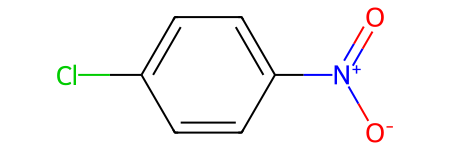

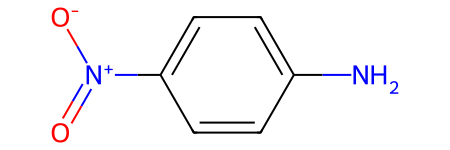

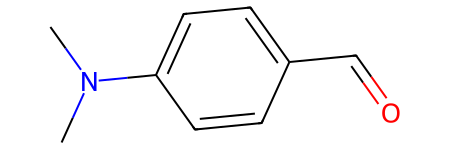

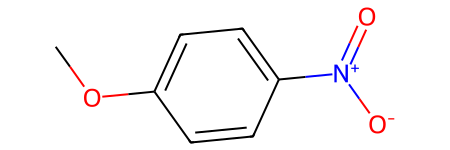

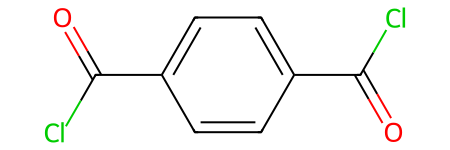

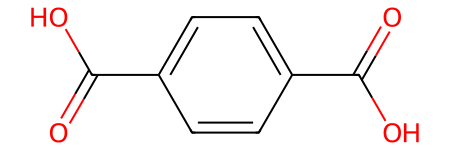

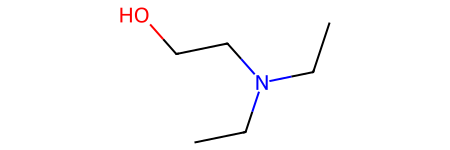

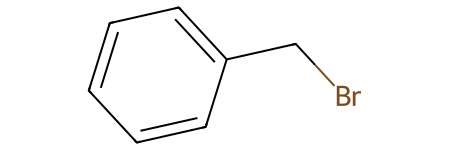

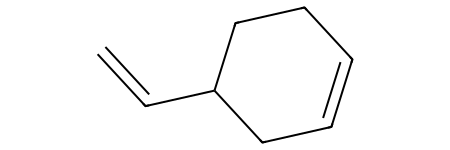

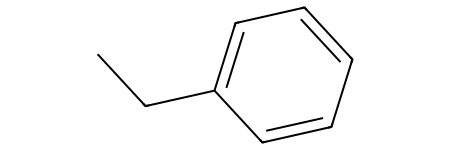

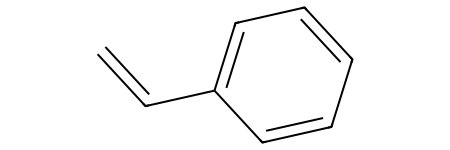

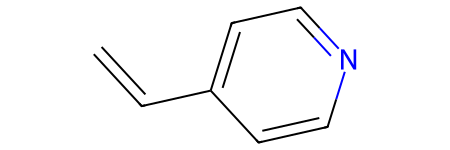

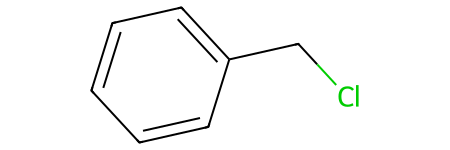

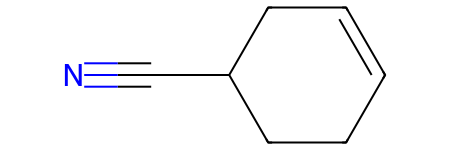

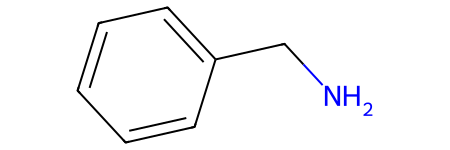

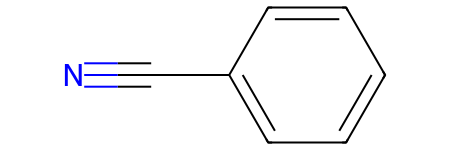

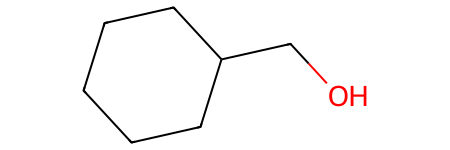

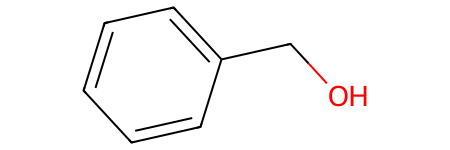

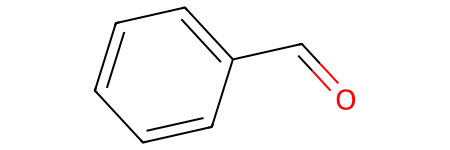

In [36]:
# rdkit tutorial steal
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
from IPython.display import SVG

mfp_generator = AllChem.GetMorganGenerator(radius=3)

for i in range(1,20):
    m1 = Chem.MolFromSmiles(df_plast_chem["Properties"]["canonical_smiles"][i])
    fp1 = mfp_generator.GetSparseCountFingerprint(m1)

    ao = AllChem.AdditionalOutput()

    ao.CollectBitInfoMap()

    fp = mfp_generator.GetFingerprint(m1,additionalOutput=ao)
    bi = ao.GetBitInfoMap()
    mfp2_svg = Draw.DrawMorganBit(m1, list(bi.keys())[1], bi, useSVG=True)
    drawer = Draw.rdMolDraw2D.MolDraw2DSVG(450, 150)
    #draw the molcule
    drawer.DrawMolecule(m1)
    drawer.FinishDrawing()
    # get the SVG string
    svg = drawer.GetDrawingText()
    # fix the svg string and display it
    display(SVG(svg.replace('svg:','')))

#DataStructs.DiceSimilarity(fp1,fp2)

In [32]:
# xgboost tutorial steal
from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=.2)
# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)
preds

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 2, 1, 0, 0, 2, 1, 1, 2, 1, 0,
       0, 0, 2, 2, 2, 0, 2, 0])